## Notebooks use to get insights in the bulls/bear ratio and use a contrarian strategy (UniGe exercise)

In [ ]:
from pathlib import Path
import pandas as pd

In [ ]:
p = Path("./input")
file = p / "Nikkei---Moving-averages.xlsx"
if not file.exists():
    files = list(p.glob("*.xls*"))
    if not files:
        raise SystemExit("No Excel files found in this folder")
    file = files[0]

df = pd.read_excel(file)
print("Using file:", file)
print("Headers:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

Using file: _5eb5b3ce7b396c6f8f8faeacce3c94bc_S_P500---Bulls-versus-bears.xlsx
Headers:
1. DATE
2. S&P 500 INDEX - PRICE
3. BULLS / BEARS RATIO


In [4]:
df.head()

,DATE,S&P 500 INDEX - PRICE,BULLS / BEARS RATIO
0,2006-01-06,1285.45,0.73
1,2006-01-13,1287.61,3.09
2,2006-01-20,1261.49,1.94
3,2006-01-27,1283.72,0.92
4,2006-02-03,1264.03,1.34


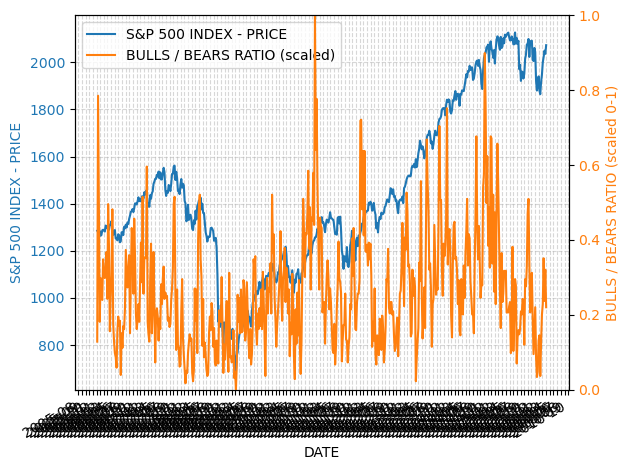

In [8]:
date_col = df.columns[0]
col2 = df.columns[1]
if df.shape[1] < 3:
    raise SystemExit("Need a third column to scale and plot on the right axis")
col3 = df.columns[2]

df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
df = df.dropna(subset=[date_col]).reset_index(drop=True)

# scale col3 to [0,1]
vals = df[col3].astype(float)
mn, mx = vals.min(), vals.max()
if pd.isna(mn) or pd.isna(mx):
    raise SystemExit("Third column contains only NaN")
if mx > mn:
    scaled = (vals - mn) / (mx - mn)
else:
    scaled = pd.Series(0.5, index=df.index)  # constant series -> center at 0.5

fig, ax = plt.subplots()
ax.plot(df[date_col], df[col2], label=str(col2), color="tab:blue")
ax.set_xlabel(date_col)
ax.set_ylabel(str(col2), color="tab:blue")
ax.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax.twinx()
ax2.plot(df[date_col], scaled, label=f"{col3} (scaled)", color="tab:orange")
ax2.set_ylim(0, 1)
ax2.set_ylabel(f"{col3} (scaled 0-1)", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

# combined legend
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper left")

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.grid(True, which="both", linestyle="--", alpha=0.5)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

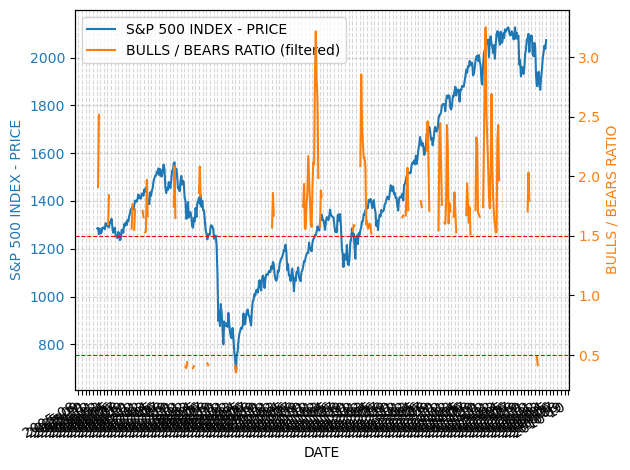

In [24]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

p = Path(".")
files = list(p.glob("*.xls*"))
if not files:
    raise SystemExit("No Excel files found in this folder")
file = files[0]

df = pd.read_excel(file)
date_col = df.columns[0]
col2 = df.columns[1]
if df.shape[1] < 3:
    raise SystemExit("Need a third column to scale and plot on the right axis")
col3 = df.columns[2]

df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
df = df.dropna(subset=[date_col]).reset_index(drop=True)

# average every 2 entries (2-point rolling mean); do not apply extra smoothing/backfill
smoothed = df[col3].astype(float).rolling(window=2).mean().fillna(df[col3].astype(float))


fig, ax = plt.subplots()
ax.plot(df[date_col], df[col2], label=str(col2), color="tab:blue")
ax.set_xlabel(date_col)
ax.set_ylabel(str(col2), color="tab:blue")
ax.tick_params(axis="y", labelcolor="tab:blue")

# average every 2 entries (2-point rolling mean); do not apply extra smoothing/backfill
avg2 = df[col3].astype(float).rolling(window=2).mean().fillna(df[col3].astype(float))
# keep only values above 1.5 or below 0.5
mask = (avg2 > 1.5) | (avg2 < 0.5)
visible = avg2.where(mask)

ax2 = ax.twinx()
ax2.plot(df[date_col], visible, linestyle="-", color="tab:orange", label=f"{col3} (filtered)")
ax2.set_ylabel(f"{col3}", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")
# threshold lines
ax2.axhline(1.5, color="red", linestyle="--", linewidth=0.8)
ax2.axhline(0.5, color="green", linestyle="--", linewidth=0.8)

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper left")

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.grid(True, which="both", linestyle="--", alpha=0.5)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [26]:
# Compute the % of the time col3 is above 1.5 or below 0.5
total = len(df)
above = (avg2 > 1.5).sum()
below = (avg2 < 0.5).sum()
print(f"Above 1.5: {above} times ({above/total:.2%})")
print(f"Below 0.5: {below} times ({below/total:.2%})")
print(f"Total either above or below: {above+below} times ({(above+below)/total:.2%})")

Above 1.5: 134 times (25.05%)
Below 0.5: 14 times (2.62%)
Total either above or below: 148 times (27.66%)


In [30]:
from pathlib import Path
import pandas as pd

p = Path(".")
files = list(p.glob("*.xls*"))
if not files:
    raise SystemExit("No Excel files found in this folder")

file = files[0]

df = pd.read_excel(file)
date_col = df.columns[0]
col2 = df.columns[1]
col3 = df.columns[2]
df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
df = df.dropna(subset=[date_col]).reset_index(drop=True).set_index(date_col)

# 2-entry average (no extra smoothing)
ratio = df[col3].astype(float).rolling(window=2).mean().fillna(df[col3].astype(float))

# weekly (week ending Friday) series
ratio_w = ratio.resample("W-FRI").last()
close_w = df[col2].resample("W-FRI").last()

# scan chronologically, one open trade at a time per side
short_trades = []
long_trades = []
in_short = False
in_long = False
short_entry = short_entry_price = None
long_entry = long_entry_price = None

for idx in ratio_w.index:
    r = ratio_w.loc[idx]
    if pd.isna(r):
        continue
    price = close_w.loc[idx]

    # Short: entry when ratio rises above 1.5, exit when it falls at-or-below 1.5
    if not in_short and r > 1.5:
        in_short = True
        short_entry = idx
        short_entry_price = price
    elif in_short and r <= 1.5:
        short_trades.append((short_entry.date(), float(short_entry_price),
                             idx.date(), float(price)))
        in_short = False
        short_entry = short_entry_price = None

    # Long: entry when ratio falls below 0.5, exit when it rises at-or-above 0.5
    if not in_long and r < 0.5:
        in_long = True
        long_entry = idx
        long_entry_price = price
    elif in_long and r >= 0.5:
        long_trades.append((long_entry.date(), float(long_entry_price),
                            idx.date(), float(price)))
        in_long = False
        long_entry = long_entry_price = None

# Compute per-trade returns and aggregates

short_returns = []
print("Short trades (entry when ratio > 1.5, exit when <= 1.5):")
for e_date, e_price, x_date, x_price in short_trades:
    # normalized return: (exit - entry) / entry, invert sign for short positions
    rtn = (x_price - e_price) / e_price
    rtn = -1.0 * rtn
    short_returns.append((e_date, rtn))
    print(f"Entry {e_date} @ {e_price:.2f}, Exit {x_date} @ {x_price:.2f}, Return {rtn:.4f}")

long_returns = []
print("\nLong trades (entry when ratio < 0.5, exit when >= 0.5):")
for e_date, e_price, x_date, x_price in long_trades:
    rtn = (x_price - e_price) / e_price
    long_returns.append((e_date, rtn))
    print(f"Entry {e_date} @ {e_price:.2f}, Exit {x_date} @ {x_price:.2f}, Return {rtn:.4f}")

# Combine trades chronologically and compute final wealth starting from $100
all_trades = []
all_trades.extend(short_returns)
all_trades.extend(long_returns)
# sort by entry date
all_trades.sort(key=lambda x: x[0])

# Compute final wealth by compounding in chronological order
wealth = 100.0
for d, r in all_trades:
    wealth *= (1 + r)

print()
print(f"Number of trades: {len(all_trades)}")
print(f"Final wealth starting from $100: ${wealth:.2f}")


Short trades (entry when ratio > 1.5, exit when <= 1.5):
Entry 2006-01-13 @ 1287.61, Exit 2006-01-27 @ 1283.72, Return 0.0030
Entry 2006-03-24 @ 1302.95, Exit 2006-03-31 @ 1294.83, Return 0.0062
Entry 2006-04-07 @ 1295.50, Exit 2006-04-21 @ 1311.28, Return -0.0122
Entry 2006-05-12 @ 1291.24, Exit 2006-05-19 @ 1267.03, Return 0.0187
Entry 2006-09-08 @ 1298.92, Exit 2006-09-15 @ 1319.87, Return -0.0161
Entry 2006-10-20 @ 1368.60, Exit 2006-11-03 @ 1364.30, Return 0.0031
Entry 2006-11-10 @ 1380.90, Exit 2006-11-24 @ 1400.95, Return -0.0145
Entry 2007-01-19 @ 1430.50, Exit 2007-02-02 @ 1448.39, Return -0.0125
Entry 2007-02-09 @ 1438.06, Exit 2007-03-09 @ 1402.85, Return 0.0245
Entry 2007-03-30 @ 1420.86, Exit 2007-04-06 @ 1443.76, Return -0.0161
Entry 2007-10-05 @ 1557.59, Exit 2007-10-26 @ 1535.28, Return 0.0143
Entry 2008-05-02 @ 1413.90, Exit 2008-05-23 @ 1375.93, Return 0.0269
Entry 2010-01-01 @ 1115.10, Exit 2010-01-22 @ 1091.76, Return 0.0209
Entry 2010-03-12 @ 1149.99, Exit 2010-03-

In [34]:
def final_wealth_grid(file_path, short_thresholds, long_thresholds, start_capital=100.0):
    p = Path(file_path)
    df = pd.read_excel(p)
    date_col = df.columns[0]
    col2 = df.columns[1]
    col3 = df.columns[2]
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df = df.dropna(subset=[date_col]).reset_index(drop=True).set_index(date_col)

    # 2-entry average (as used above)
    ratio = df[col3].astype(float).rolling(window=2).mean().fillna(df[col3].astype(float))
    ratio_w = ratio.resample("W-FRI").last()
    close_w = df[col2].resample("W-FRI").last()

    records = []
    for short_th in short_thresholds:
        for long_th in long_thresholds:
            short_trades = []
            long_trades = []
            in_short = False
            in_long = False
            short_entry_price = None
            long_entry_price = None

            for idx in ratio_w.index:
                val = ratio_w.loc[idx]
                if pd.isna(val):
                    continue
                price = close_w.loc[idx]

                if not in_short and val > short_th:
                    in_short = True
                    short_entry_price = price
                    short_entry_date = idx
                elif in_short and val <= short_th:
                    short_trades.append((short_entry_date.date(), float(short_entry_price), idx.date(), float(price)))
                    in_short = False
                    short_entry_price = None

                if not in_long and val < long_th:
                    in_long = True
                    long_entry_price = price
                    long_entry_date = idx
                elif in_long and val >= long_th:
                    long_trades.append((long_entry_date.date(), float(long_entry_price), idx.date(), float(price)))
                    in_long = False
                    long_entry_price = None

            all_returns = []
            for e_date, e_price, x_date, x_price in short_trades:
                rtn = -1.0 * ((x_price - e_price) / e_price)
                all_returns.append((e_date, rtn))
            for e_date, e_price, x_date, x_price in long_trades:
                rtn = (x_price - e_price) / e_price
                all_returns.append((e_date, rtn))

            # sort chronologically by entry date
            all_returns.sort(key=lambda x: x[0])
            wealth = float(start_capital)
            for d, rt in all_returns:
                wealth *= (1 + rt)

            records.append({
                "short_th": float(short_th),
                "long_th": float(long_th),
                "final_wealth": wealth,
                "n_trades": len(all_returns),
            })

    return pd.DataFrame.from_records(records)

Best: short=1.75, long=0.5, final_wealth=$107.96, trades=32


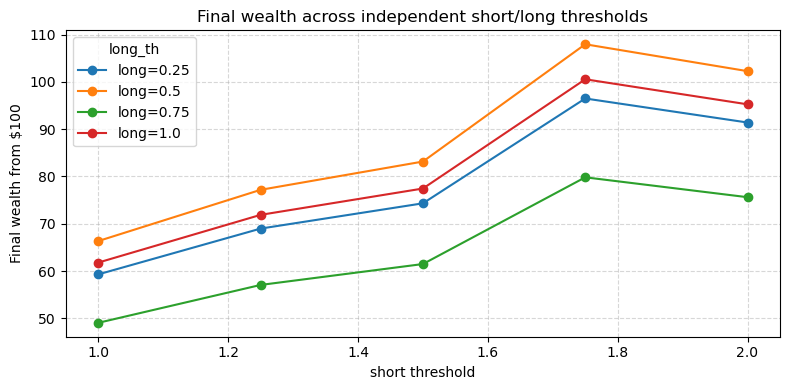

In [35]:
# Sweep independent short and long thresholds and plot final wealth grid
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Example usage: provide independent arrays for short and long thresholds

p = Path(".")
files = list(p.glob("*.xls*"))
if not files:
    raise SystemExit("No Excel files found in this folder")

file = files[0]


short_thresholds = [1.0, 1.25, 1.5, 1.75, 2.0]
long_thresholds = [0.25, 0.5, 0.75, 1.0]

df_grid = final_wealth_grid(file, short_thresholds, long_thresholds)

# print best combination
best = df_grid.loc[df_grid["final_wealth"].idxmax()]
print(f"Best: short={best.short_th}, long={best.long_th}, final_wealth=${best.final_wealth:.2f}, trades={int(best.n_trades)}")

# Plot wealth vs short threshold for each long threshold
plt.figure(figsize=(8,4))
for long_th in sorted(set(df_grid.long_th)):
    sub = df_grid[df_grid.long_th == long_th].sort_values("short_th")
    plt.plot(sub.short_th, sub.final_wealth, marker='o', label=f"long={long_th}")

plt.xlabel("short threshold")
plt.ylabel("Final wealth from $100")
plt.title("Final wealth across independent short/long thresholds")
plt.legend(title='long_th')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
